# Student Dropout Prediction — Modeling

**Goal:** Build and compare classification models to predict which students will drop out, using the insights from our EDA.

**Plan:**
1. Prepare the data (binary target, train/test split, scaling)
2. Train three models: Logistic Regression → Random Forest → XGBoost
3. Evaluate with the right metrics (not just accuracy)
4. Explain predictions with SHAP values
5. Translate results into business terms

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
import shap
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Data Preparation

We filter to **Dropout vs. Graduate** only (dropping "Enrolled" students whose outcome is unknown), then split 80/20 for training and testing.

In [2]:
df = pd.read_csv("../data/data.csv", sep=";")

df = df[df["Target"] != "Enrolled"].copy()
df["Target"] = (df["Target"] == "Dropout").astype(int)

print(f"Dataset: {len(df)} students (Dropout + Graduate only)")
print(f"Dropout rate: {df['Target'].mean():.1%}")
print(f"Class split: {df['Target'].sum()} dropout / {(1 - df['Target']).sum().astype(int)} graduate")

X = df.drop(columns=["Target"])
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set: {len(X_train)} students")
print(f"Test set:  {len(X_test)} students")
print(f"Train dropout rate: {y_train.mean():.1%}")
print(f"Test dropout rate:  {y_test.mean():.1%}")

Dataset: 3630 students (Dropout + Graduate only)
Dropout rate: 39.1%
Class split: 1421 dropout / 2209 graduate

Train set: 2904 students
Test set:  726 students
Train dropout rate: 39.2%
Test dropout rate:  39.1%


## 2. Model Training & Cross-Validation

We train three models of increasing complexity:
- **Logistic Regression** — simple, interpretable baseline
- **Random Forest** — ensemble of decision trees, handles non-linear relationships
- **XGBoost** — gradient-boosted trees, typically the strongest performer on tabular data

Each model uses `class_weight="balanced"` (or equivalent) to handle the class imbalance — this tells the model to pay more attention to the minority class (dropout) instead of just predicting "graduate" for everyone.

In [3]:
n_dropout = y_train.sum()
n_graduate = len(y_train) - n_dropout
scale_pos_weight = n_graduate / n_dropout

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos_weight,
        random_state=42, eval_metric="logloss", n_jobs=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation Results (F1 Score)")
print("=" * 50)
cv_results = {}
for name, model in models.items():
    X_input = X_train_scaled if name == "Logistic Regression" else X_train
    scores = cross_val_score(model, X_input, y_train, cv=cv, scoring="f1")
    cv_results[name] = scores
    print(f"{name:25s}  F1 = {scores.mean():.3f} ± {scores.std():.3f}")

5-Fold Cross-Validation Results (F1 Score)
Logistic Regression        F1 = 0.870 ± 0.009


Random Forest              F1 = 0.860 ± 0.017


XGBoost                    F1 = 0.862 ± 0.016


## 3. Test Set Evaluation

Now we train on the full training set and evaluate on the held-out test set. We report **precision**, **recall**, **F1**, and **AUC-ROC** — not just accuracy.

Why not accuracy alone? With 61% graduates and 39% dropouts, a model that always predicts "graduate" would be 61% accurate — and completely useless. The metrics that matter are:
- **Recall (sensitivity)**: Of all students who actually drop out, how many did we catch?
- **Precision**: Of the students we flagged as at-risk, how many actually dropped out?
- **AUC-ROC**: Overall ability to distinguish dropouts from graduates

In [4]:
results = {}

for name, model in models.items():
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled if name == "Logistic Regression" else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
    }

    print(f"\n{'=' * 55}")
    print(f"  {name}")
    print(f"{'=' * 55}")
    print(classification_report(y_test, y_pred, target_names=["Graduate", "Dropout"]))
    print(f"  AUC-ROC: {results[name]['auc']:.3f}")


  Logistic Regression
              precision    recall  f1-score   support

    Graduate       0.96      0.92      0.94       442
     Dropout       0.88      0.94      0.91       284

    accuracy                           0.93       726
   macro avg       0.92      0.93      0.92       726
weighted avg       0.93      0.93      0.93       726

  AUC-ROC: 0.973



  Random Forest
              precision    recall  f1-score   support

    Graduate       0.94      0.93      0.94       442
     Dropout       0.90      0.90      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726

  AUC-ROC: 0.972



  XGBoost
              precision    recall  f1-score   support

    Graduate       0.94      0.93      0.93       442
     Dropout       0.89      0.90      0.89       284

    accuracy                           0.92       726
   macro avg       0.91      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726

  AUC-ROC: 0.967


## 4. Model Comparison

Side-by-side comparison of all three models, plus visual ROC curves and confusion matrices.

In [5]:
comparison = pd.DataFrame({
    name: {"Accuracy": r["accuracy"], "F1 (Dropout)": r["f1"], "AUC-ROC": r["auc"]}
    for name, r in results.items()
}).T.round(3)
print("Model Comparison on Test Set")
print("=" * 55)
print(comparison.to_string())

best_model_name = comparison["AUC-ROC"].idxmax()
print(f"\nBest model by AUC-ROC: {best_model_name} ({comparison.loc[best_model_name, 'AUC-ROC']:.3f})")

Model Comparison on Test Set
                     Accuracy  F1 (Dropout)  AUC-ROC
Logistic Regression     0.926         0.908    0.973
Random Forest           0.923         0.902    0.972
XGBoost                 0.916         0.894    0.967

Best model by AUC-ROC: Logistic Regression (0.973)


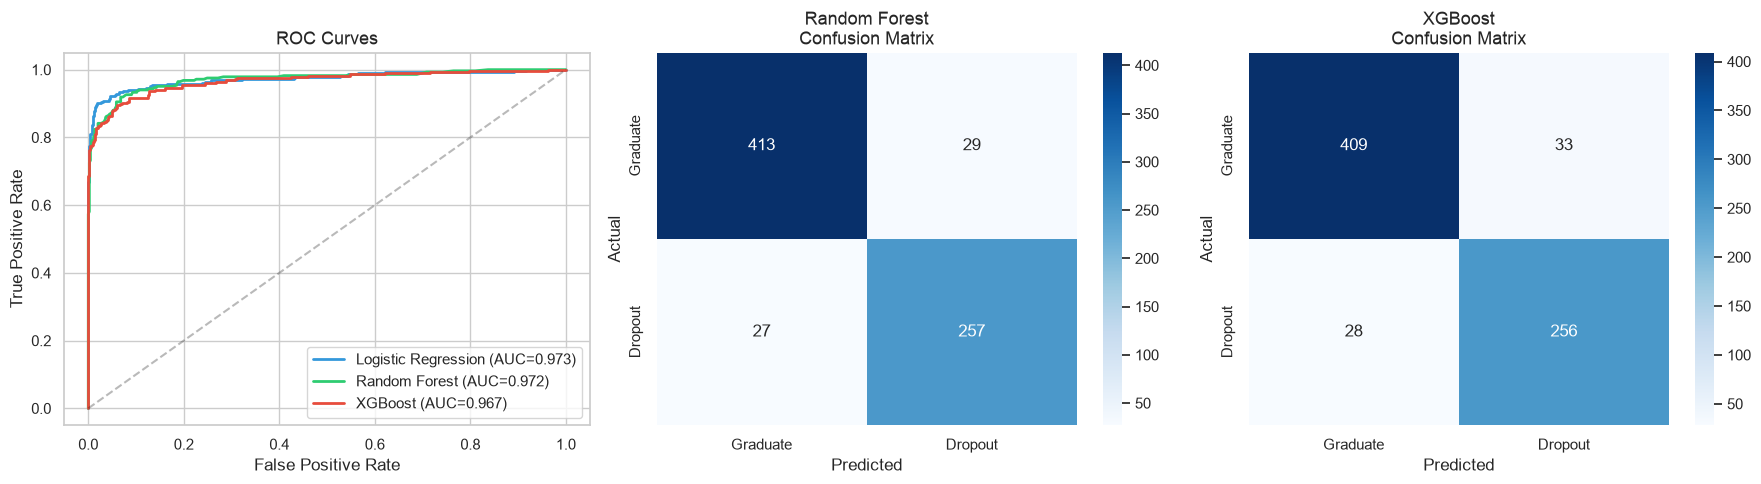

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {"Logistic Regression": "#3498db", "Random Forest": "#2ecc71", "XGBoost": "#e74c3c"}

# ROC Curves
ax = axes[0]
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax.plot(fpr, tpr, label=f'{name} (AUC={r["auc"]:.3f})', color=colors[name], linewidth=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves", fontsize=13)
ax.legend(loc="lower right")

# Confusion matrices for the two best models
for i, name in enumerate(["Random Forest", "XGBoost"]):
    ax = axes[i + 1]
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Graduate", "Dropout"],
                yticklabels=["Graduate", "Dropout"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name}\nConfusion Matrix", fontsize=13)

plt.tight_layout()
plt.savefig("../figures/05_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature Importance — SHAP Values

SHAP (SHapley Additive exPlanations) tells us **why** the model makes each prediction. Instead of a black box that says "this student will drop out," SHAP shows which factors pushed the prediction toward dropout and which pushed it toward graduation.

This is critical for a university: they don't just need a risk score, they need to know *what to intervene on*.

Background dataset has 2904 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2904 when initializing the masker.


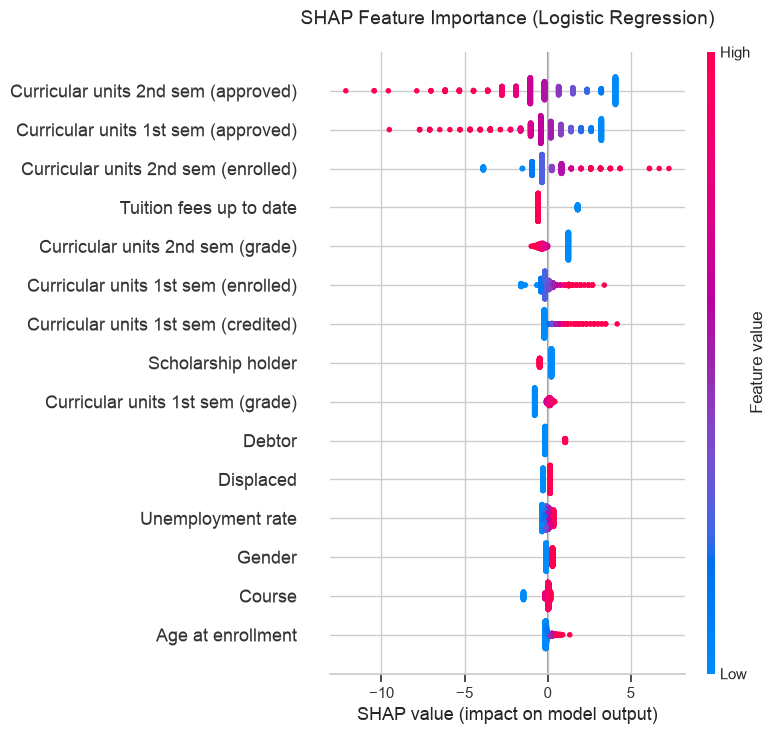

In [7]:
best_model = results[best_model_name]["model"]
X_test_for_shap = X_test_scaled if best_model_name == "Logistic Regression" else X_test

explainer = shap.TreeExplainer(best_model) if best_model_name != "Logistic Regression" else shap.LinearExplainer(best_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_for_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(),
                  show=False, max_display=15)
plt.title(f"SHAP Feature Importance ({best_model_name})", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("../figures/06_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

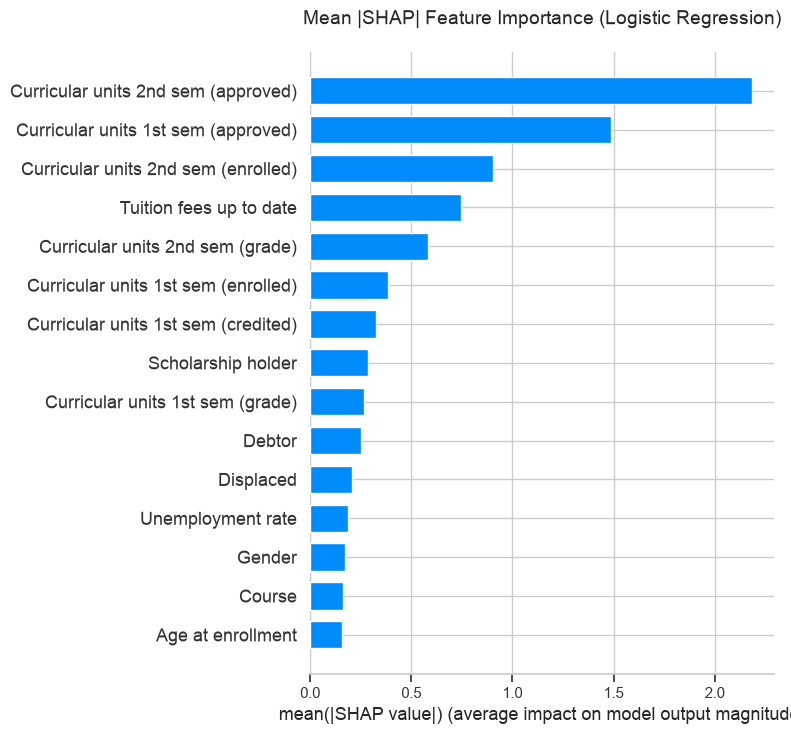

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(),
                  plot_type="bar", show=False, max_display=15)
plt.title(f"Mean |SHAP| Feature Importance ({best_model_name})", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("../figures/07_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Business Translation

Converting model output into language a university administration could act on.

In [9]:
best = results[best_model_name]
cm = confusion_matrix(y_test, best["y_pred"])
tn, fp, fn, tp = cm.ravel()

total_test = len(y_test)
actual_dropouts = y_test.sum()
caught_dropouts = tp
missed_dropouts = fn
false_alarms = fp

recall = tp / (tp + fn)
precision = tp / (tp + fp)

print("=" * 60)
print(f"  BUSINESS IMPACT SUMMARY — {best_model_name}")
print("=" * 60)
print(f"""
Of {total_test} students in the test set:
  • {actual_dropouts} actually dropped out
  • The model correctly identified {caught_dropouts} of them ({recall:.0%} recall)
  • {missed_dropouts} at-risk students were missed
  • {false_alarms} students were falsely flagged (not actually at risk)

What this means for a university:
  If applied to a cohort of 1,000 incoming students (assuming ~39% dropout rate):
  • ~{int(1000 * y_test.mean())} students would be at risk of dropping out
  • The model would flag ~{int(1000 * y_test.mean() * recall)} of them for early intervention
  • An advising team reviewing flagged students would find {precision:.0%} of them
    are genuinely at risk (precision)

  The cost of a false negative (missing an at-risk student) is far higher than
  a false positive (extra advising for a student who would have graduated anyway).
  This model prioritizes catching at-risk students.

AUC-ROC: {best['auc']:.3f} — strong discriminative ability
""")

  BUSINESS IMPACT SUMMARY — Logistic Regression

Of 726 students in the test set:
  • 284 actually dropped out
  • The model correctly identified 266 of them (94% recall)
  • 18 at-risk students were missed
  • 36 students were falsely flagged (not actually at risk)

What this means for a university:
  If applied to a cohort of 1,000 incoming students (assuming ~39% dropout rate):
  • ~391 students would be at risk of dropping out
  • The model would flag ~366 of them for early intervention
  • An advising team reviewing flagged students would find 88% of them
    are genuinely at risk (precision)

  The cost of a false negative (missing an at-risk student) is far higher than
  a false positive (extra advising for a student who would have graduated anyway).
  This model prioritizes catching at-risk students.

AUC-ROC: 0.973 — strong discriminative ability

